<a href="https://colab.research.google.com/github/carlosvasquez3/M.Sc.-in-Data-Science/blob/main/Fundamentos_bases_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gestión médica

En este proyecto se desarrolla un sistema de gestión para una clínica médica utilizando SQLite3 en Python, con el objetivo de administrar de manera organizada la información de pacientes, médicos y citas. Se diseña una base de datos relacional que permite registrar pacientes con su historial clínico, médicos con su especialidad y gestionar citas médicas incluyendo fecha, hora, diagnóstico y estado. Además, se implementan consultas SQL para visualizar citas pendientes, agrupar citas por hora y consultar el historial de los pacientes, aplicando así los conceptos fundamentales de bases de datos y programación vistos en clase.


##Integrantes del grupo:

*   Acosta Perez, Camilo Andres
*   Restrepo Giraldo, Luis Miguel
*   Vasquez Ortiz, Carlos Enrique

#Sistema de gestión

Para el sistema de gestión se empieza por importar las librerías y crear las bases de datos.

In [ ]:
#Se importan las librerías utilizadas dentro del ejercicio
import sqlite3
from datetime import datetime
from tabulate import tabulate
from rich.console import Console
from rich.panel import Panel
from rich.prompt import Prompt

console = Console()

##Base de datos con las tablas para pacientes, médico y citas.

In [ ]:
#Se crea la Base de Datos de la clínica
DB_NAME = "clinica.db"

def get_conn():
    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA foreign_keys = ON;")
    return conn

#Se crean las tablas pertenecientes a los pacientes, médicos y citas
def init_db(conn):
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS pacientes (               -- Se crea la tabla paciente
        id_paciente INTEGER PRIMARY KEY AUTOINCREMENT,   -- Identificador único del paciente
        nombre_paciente TEXT NOT NULL,                   -- Nombre del paciente
        edad INTEGER,                                    -- Edad del paciente
        direccion TEXT,                                  -- Dirección del paciente
        telefono TEXT,                                   -- Número de teléfono del paciente
        email TEXT,                                      -- Dirección de correo electrónico del paciente
        historia_clinica TEXT                            -- Historia clínica del paciente
)
    );

    CREATE TABLE IF NOT EXISTS medicos (                 -- Se crea la tabla médico
        id_medico INTEGER PRIMARY KEY AUTOINCREMENT,     -- Identificador único del médico
        nombre_medico TEXT NOT NULL,                     -- Nombre del médico
        especialidad TEXT NOT NULL                       -- Especialidad del médico
    );

    CREATE TABLE IF NOT EXISTS citas (                   -- Se crea la tabla citas
        id_cita INTEGER PRIMARY KEY AUTOINCREMENT,       -- Identificador único de la cita
        id_paciente INTEGER NOT NULL,                    -- Identificador del paciente
        id_medico INTEGER NOT NULL,                      -- Identificador del médico
        fecha TEXT NOT NULL,                             -- Fecha de la cita
        hora TEXT NOT NULL,                              -- Hora de la cita
        diagnostico TEXT,
        estado TEXT NOT NULL DEFAULT 'Pendiente' CHECK(estado IN ('Pendiente','Confirmada','Cancelada')),  -- Estado de la cita (Pendiente, Confirmada, Cancelada)
        FOREIGN KEY (id_paciente) REFERENCES pacientes(id_paciente),              -- Relación con la clave foránea del paciente
        FOREIGN KEY (id_medico) REFERENCES medicos(id_medico) ON DELETE CASCADE   -- Relación con la clave foránea del médico

    );

    -- Evita 2 citas para el mismo médico en la misma fecha/hora
    CREATE UNIQUE INDEX IF NOT EXISTS uq_cita_medico_fecha_hora
    ON citas(id_medico, fecha, hora);
    """)
    conn.commit()

def seed_data(conn):
    cur = conn.cursor()

    cur.execute("SELECT COUNT(*) AS n FROM pacientes;")
    if cur.fetchone()["n"] == 0:                                          #Se insertan los datos de los pacientes, ejemplos sacados de una navegación (consulta)
        cur.executemany("""
            INSERT INTO pacientes(nombre_paciente, edad, telefono, historia_clinica)
            VALUES(?,?,?,?)
        """, [
        ('Ana Torres', 28, '3001234567', 'Paciente con antecedentes de asma leve.'),
        ('Luis Pérez', 35, '3012345678', 'Hipertensión controlada con medicación.'),
        ('Marta Gómez', 42, '3023456789', 'Diabetes tipo 2 en seguimiento.'),
        ('Carlos Ramírez', 50, '3034567890', 'Historial de cirugía de rodilla en 2020.'),
        ('Laura Sánchez', 31, '3045678901', 'Alergia a la penicilina.'),
        ('Diego Ríos', 27, '3056789012', 'Paciente sano, chequeo anual.'),
        ('Sofía Martínez', 38, '3067890123', 'Migrañas frecuentes.'),
        ('Andrés López', 45, '3078901234', 'Colesterol alto en tratamiento.'),
        ('Valentina Castro', 29, '3089012345', 'Anemia leve diagnosticada en 2023.'),
        ('Jorge Herrera', 60, '3090123456', 'Enfermedad cardíaca estable.'),
        ('Natalia Moreno', 33, '3101234567', 'Problemas de tiroides.'),
        ('Camilo Vargas', 40, '3112345678', 'Dolor lumbar crónico.'),
        ('Paula Jiménez', 26, '3123456789', 'Chequeo general sin novedades.'),
        ('Ricardo Díaz', 55, '3134567890', 'Historial de gastritis crónica.'),
        ('Daniela Ruiz', 37, '3145678901', 'Ansiedad en tratamiento psicológico.'),
        ('Sebastián Ortiz', 48, '3156789012', 'Presión arterial elevada.'),
        ('Mariana León', 30, '3167890123', 'Paciente embarazada, control prenatal.'),
        ('Felipe Navarro', 41, '3178901234', 'Lesión deportiva en rehabilitación.')
        ])
                                                                           #Se insertan los datos de médicos, ejemplos sacados de una navegación (consulta)
    cur.execute("SELECT COUNT(*) AS n FROM medicos;")
    if cur.fetchone()["n"] == 0:
        cur.executemany("""
            INSERT INTO medicos(nombre_medico, especialidad)
            VALUES(?,?)
        """, [
            ('Dr. Juan Martínez', 'Medicina General'),
            ('Dra. Carolina López', 'Pediatría'),
            ('Dr. Andrés Gómez', 'Cardiología'),
            ('Dra. Laura Sánchez', 'Dermatología'),
            ('Dr. Felipe Herrera', 'Ortopedia'),
            ('Dra. Natalia Ruiz', 'Ginecología'),
            ('Dr. Camilo Vargas', 'Neurología'),
            ('Dra. Sofía Torres', 'Endocrinología'),
            ('Dr. Ricardo Díaz', 'Psiquiatría'),
            ('Dra. Daniela Moreno', 'Oftalmología'),
            ('Dr. Sebastián Castro', 'Urología'),
            ('Dra. Mariana León', 'Oncología'),
            ('Dr. Jorge Ramírez', 'Gastroenterología'),
            ('Dra. Paula Jiménez', 'Reumatología'),
            ('Dr. Diego Ríos', 'Cirugía General')
        ])
                                                                            #Se insertan los datos de las, ejemplos sacados de una navegación (consulta)
    cur.execute("SELECT COUNT(*) AS n FROM citas;")
    if cur.fetchone()["n"] == 0:
        cur.executemany("""
            INSERT INTO citas(id_paciente, id_medico, fecha, hora, diagnostico, estado)
            VALUES(?,?,?,?,?,?)
        """, [
           (1,1,'2026-03-01','08:00','Chequeo general','Pendiente'),
           (2,2,'2026-03-01','09:00','Control pediátrico','Pendiente'),
           (3,3,'2026-03-01','10:00','Revisión cardíaca','Pendiente'),
           (4,4,'2026-03-01','11:00','Evaluación dermatológica','Pendiente'),
           (5,5,'2026-03-01','16:00','Dolor de rodilla','Pendiente'),
           (6,6,'2026-03-02','08:00','Control ginecológico','Pendiente'),
           (7,7,'2026-03-02','09:00','Dolor de cabeza frecuente','Pendiente'),
           (8,8,'2026-03-02','10:00','Control de tiroides','Pendiente'),
           (9,9,'2026-03-02','11:00','Ansiedad','Pendiente'),
           (10,10,'2026-03-02','14:00','Examen visual','Pendiente'),
           (11,11,'2026-03-03','08:00','Control urológico','Pendiente'),
           (12,12,'2026-03-03','09:00','Seguimiento oncológico','Pendiente'),
           (13,13,'2026-03-03','10:00','Dolor estomacal','Pendiente'),
           (14,14,'2026-03-03','11:00','Artritis','Pendiente'),
           (15,15,'2026-03-03','14:00','Consulta quirúrgica','Pendiente'),
           (16,1,'2026-03-04','08:00','Chequeo general','Pendiente'),
           (17,2,'2026-03-04','09:00','Control infantil','Pendiente'),
           (18,3,'2026-03-04','10:00','Hipertensión','Pendiente'),
           (1,4,'2026-03-04','11:00','Alergia en piel','Pendiente'),
           (2,5,'2026-03-04','14:00','Lesión deportiva','Pendiente'),
           (3,6,'2026-03-05','08:00','Control prenatal','Pendiente'),
           (4,7,'2026-03-05','09:00','Migraña crónica','Pendiente'),
           (5,8,'2026-03-05','10:00','Diabetes','Pendiente'),
           (6,9,'2026-03-05','11:00','Evaluación psicológica','Pendiente'),
           (7,10,'2026-03-05','14:00','Examen visual','Pendiente'),
           (8,11,'2026-03-06','08:00','Revisión próstata','Pendiente'),
           (9,12,'2026-03-06','09:00','Tratamiento cáncer','Pendiente'),
           (10,13,'2026-03-06','10:00','Gastritis','Pendiente'),
           (11,14,'2026-03-06','11:00','Dolor articular','Pendiente'),
           (12,15,'2026-03-06','14:00','Evaluación cirugía','Pendiente'),
           (13,1,'2026-03-07','08:00','Chequeo anual','Pendiente'),
           (14,2,'2026-03-07','09:00','Vacunación','Pendiente'),
           (15,3,'2026-03-07','10:00','Arritmia','Pendiente'),
           (16,4,'2026-03-07','11:00','Acné severo','Pendiente'),
           (17,5,'2026-03-07','16:00','Dolor de hombro','Pendiente'),
           (18,6,'2026-03-08','08:00','Revisión ginecológica','Pendiente'),
           (1,7,'2026-03-08','09:00','Dolor cervical','Pendiente'),
           (2,8,'2026-03-08','10:00','Control hormonal','Pendiente'),
           (3,9,'2026-03-08','11:00','Estrés','Pendiente'),
           (4,10,'2026-03-08','14:00','Control visual','Pendiente'),
           (5,11,'2026-03-09','08:00','Problema urinario','Pendiente'),
           (6,12,'2026-03-09','09:00','Revisión tumoral','Pendiente'),
           (7,13,'2026-03-09','10:00','Dolor abdominal','Pendiente'),
           (8,14,'2026-03-09','11:00','Revisión reumatológica','Pendiente'),
           (9,15,'2026-03-09','14:00','Valoración quirúrgica','Pendiente')
        ])

    conn.commit()

conn = get_conn()
init_db(conn)
seed_data(conn)

print("Base de datos lista:", DB_NAME)

*Impresion de códigos aquí

##Diagrama Entidad-Relación

En el diagrama se observan dos relaciones de uno a muchos. La primera es entre pacientes y citas, donde un paciente puede tener varias citas médicas registradas, pero cada cita pertenece únicamente a un paciente. La segunda relación es entre médicos y citas, ya que un médico puede atender muchas citas, mientras que cada cita está asignada a un solo médico. De esta forma, la tabla de citas conecta la información de pacientes y médicos dentro del sistema.


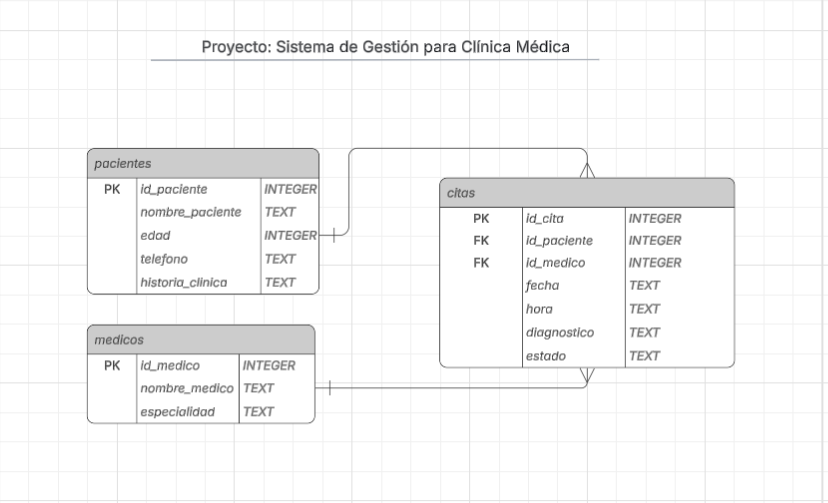

## Funcionalidades básicas.



El sistema permite registrar nuevos pacientes y médicos, agendar, modificar y cancelar citas, así como consultar el historial médico de un paciente.

Registrar nuevos pacientes y médicos: Permite ingresar y almacenar la información básica de pacientes y médicos en el sistema.

In [10]:
#pedir datos

def pedir_int(msg):
    while True:
        try:
            return int(input(msg))
        except ValueError:
            print("Debe ser un número entero.")

def registrar_paciente(conn):
    nombre = input("Por favor, ingrese el nombre:").strip()
    edad = pedir_int("Ingrese la edad del paciente: ")
    telefono = input("Ingrese el número de teléfono del paciente: ").strip()
    historia = input("Por favor, ingrese la historia clínica del paciente: ").strip()

    conn.execute("""
        INSERT INTO pacientes(nombre_paciente, edad, telefono, historia_clinica)
        VALUES(?,?,?,?)
    """, (nombre, edad, telefono, historia))
    conn.commit()
    print("\n========== REGISTRO EXITOSO ==========")
    print("El paciente fue ingresado correctamente")
    print("======================================\n")

In [ ]:
#pedir datos
def registrar_medico(conn):
    nombre = input("Por favor, ingrese el nombre del médico: ").strip()
    especialidad = input("Ingrese la especialidad del médico: ").strip()

    conn.execute("""
        INSERT INTO medicos(nombre_medico, especialidad)
        VALUES(?,?)
    """, (nombre, especialidad))
    conn.commit()
    print("\n========== ÉXITO ==========")
    print("El médico fue ingresado correctamente")
    print("===========================\n")

Agendar, modificar y cancelar citas: Permite programar nuevas citas, actualizar la información de citas existentes o cancelarlas cuando sea necesario.

In [5]:
#agendar citas

from datetime import datetime
import sqlite3

def pedir_fecha(msg="Ingrese la fecha (YYYY-MM-DD): "):
    while True:
        s = input(msg).strip()
        try:
            datetime.strptime(s, "%Y-%m-%d")
            return s
        except ValueError:
            print("Fecha inválida. Usa YYYY-MM-DD.")

def pedir_hora(msg="Ingrese la hora (HH:MM 24h): "):
    while True:
        s = input(msg).strip()
        try:
            datetime.strptime(s, "%H:%M")
            return s
        except ValueError:
            print("Hora inválida. Usa HH:MM en formato 24h.")

def existe_paciente(conn, id_paciente):
    cur = conn.cursor()
    cur.execute("SELECT 1 FROM pacientes WHERE id_paciente = ?", (id_paciente,))
    return cur.fetchone() is not None

def existe_medico(conn, id_medico):
    cur = conn.cursor()
    cur.execute("SELECT 1 FROM medicos WHERE id_medico = ?", (id_medico,))
    return cur.fetchone() is not None

def agendar_cita(conn):
    id_paciente = pedir_int("Ingrese el ID del paciente: ")
    id_medico = pedir_int("Ingrese el ID del doctor: ")

    if not existe_paciente(conn, id_paciente):
        print("\n========== ERROR ==========")
        print("El paciente no existe")
        print("===========================\n")
        return

    if not existe_medico(conn, id_medico):
        print("\n========== ERROR ==========")
        print("El doctor no existe")
        print("===========================\n")
        return

    fecha = pedir_fecha()
    hora = pedir_hora()
    diagnostico = input("Por favor, indique el motivo de su consulta: ").strip()

    try:
        conn.execute("""
            INSERT INTO citas(id_paciente, id_medico, fecha, hora, diagnostico, estado)
            VALUES(?,?,?,?,?,'Pendiente')
        """, (id_paciente, id_medico, fecha, hora, diagnostico))
        conn.commit()

        print("\n========== OK ==========")
        print("Cita registrada correctamente")
        print("========================\n")

    except sqlite3.IntegrityError:
        print("\n========== ERROR ==========")
        print("Ya existe una cita para ese médico en esa fecha y hora.")
        print("===========================\n")

In [ ]:
#modificar o cancelar citas

import sqlite3
from datetime import datetime

def modificar_cita(conn):
    id_cita = pedir_int("ID de la cita a modificar: ")
    cur = conn.cursor()
    cur.execute("SELECT * FROM citas WHERE id_cita = ?", (id_cita,))
    cita = cur.fetchone()

    if not cita:
        print("No existe esa cita.")
        return

    print("Deja vacío para conservar el valor actual.")
    nuevo_paciente = input(f"ID paciente actual ({cita['id_paciente']}): ").strip()
    nuevo_medico = input(f"ID médico actual ({cita['id_medico']}): ").strip()
    nueva_fecha = input(f"Fecha actual ({cita['fecha']}) YYYY-MM-DD: ").strip()
    nueva_hora = input(f"Hora actual ({cita['hora']}) HH:MM: ").strip()
    nuevo_diag = input("Nuevo diagnóstico: ").strip()

    id_paciente = int(nuevo_paciente) if nuevo_paciente else cita["id_paciente"]
    id_medico = int(nuevo_medico) if nuevo_medico else cita["id_medico"]
    fecha = nueva_fecha if nueva_fecha else cita["fecha"]
    hora = nueva_hora if nueva_hora else cita["hora"]
    diagnostico = nuevo_diag if nuevo_diag else cita["diagnostico"]

    if not existe_paciente(conn, id_paciente):
        print("El paciente no existe.")
        return
    if not existe_medico(conn, id_medico):
        print("El médico no existe.")
        return

    datetime.strptime(fecha, "%Y-%m-%d")
    datetime.strptime(hora, "%H:%M")

    try:
        conn.execute("""
            UPDATE citas
            SET id_paciente=?, id_medico=?, fecha=?, hora=?, diagnostico=?
            WHERE id_cita=?
        """, (id_paciente, id_medico, fecha, hora, diagnostico, id_cita))
        conn.commit()
        print("Cita modificada.")
    except sqlite3.IntegrityError:
        print("Choque de agenda: ya hay cita para ese médico en esa fecha/hora.")

def cancelar_cita(conn):
    id_cita = pedir_int("ID de la cita a cancelar: ")
    cur = conn.cursor()
    cur.execute("SELECT 1 FROM citas WHERE id_cita = ?", (id_cita,))
    if not cur.fetchone():
        print("No existe esa cita.")
        return

    conn.execute("UPDATE citas SET estado='Cancelada' WHERE id_cita=?", (id_cita,))
    conn.commit()
    print("Cita cancelada.")

def menu_citas(conn):
    while True:
        print("\n--- Manejo de citas ---")
        print("1) Agendar")
        print("2) Modificar")
        print("3) Cancelar")
        print("0) Volver")
        op = input("Elige una opción: ").strip()

        if op == "0":
            break
        elif op == "1":
            agendar_cita(conn)
        elif op == "2":
            modificar_cita(conn)
        elif op == "3":
            cancelar_cita(conn)
        else:
            print("Opción inválida.")


Buscar historial médico de un paciente: Permite consultar los registros y antecedentes médicos asociados a un paciente registrado en el sistema.

In [ ]:
#buscar historial medico del paciente

from tabulate import tabulate

def buscar_historial(conn):
    id_paciente = pedir_int("Ingrese el ID del paciente: ")

    cur = conn.cursor()
    cur.execute("SELECT * FROM pacientes WHERE id_paciente = ?", (id_paciente,))
    fila = cur.fetchone()

    if not fila:
        print("No existe ese paciente.")
        return

    print(tabulate([dict(fila)], headers="keys", tablefmt="grid"))

## Consultas avanzadas.

Aquí se encontraran las funciones de las consultas avanzadas que se podrán hacer en el sistema de gestión médico.

In [ ]:
# Se crea la función para consultar las citas pendientes de un médico específico desde la fecha actual
def citas_pendientes(conn):  #Recibe conn en la definición
    medico_consulta = input("Ingrese el ID del médico que desea consultar: ")  # Se solicita el ID del médico que se desea consultar

    consulta = f"""
    SELECT *                      -- Se seleccionan todas las columnas de la tabla citas
    FROM citas                    -- Se utiliza la tabla citas
    WHERE id_medico = ?           -- Se filtra por el ID del médico ingresado
    AND fecha >= DATE('now')     -- Se muestran solo las citas con fecha igual o posterior al día actual
    AND estado = 'Pendiente'      -- Se filtran únicamente las citas con estado Pendiente
    ORDER BY fecha, hora          -- Se ordenan los resultados por fecha y hora
    """
    cursor = conn.cursor()
    cursor.execute(consulta, (medico_consulta,))     # Ejecutamos la consulta en la base de datos
    resultados = cursor.fetchall()  # Se almacenan todos los registros obtenidos

    contador = 0                  # Se inicializa un contador para contar las citas encontradas

    for fila in resultados:       # Se recorren los resultados obtenidos
        print(fila)               # Se imprime cada cita encontrada
        contador += 1             # Se incrementa el contador por cada cita

    print("Total de citas pendientes:", contador)  # Se muestra el total de citas pendientes encontradas



Ingrese el ID del médico que desea consultar: 5
(5, 5, 5, '2026-03-01', '16:00', 'Dolor de rodilla', 'Pendiente')
(20, 2, 5, '2026-03-04', '14:00', 'Lesión deportiva', 'Pendiente')
(35, 17, 5, '2026-03-07', '16:00', 'Dolor de hombro', 'Pendiente')
Total de citas pendientes: 3


In [ ]:
#Función para agrupar las citas por hora
def agrupar_citas_por_hora():
  cursor = conn.cursor()
  cursor.execute("""          -- Se utiliza sql para agrupar las citas por hora
  SELECT hora, COUNT(*)       -- Se selecciona la hora y la cantidad de citas
  FROM citas                  -- utilizamos la tbale citas
  GROUP BY hora               -- Se agrupa y ordena por hora
  ORDER BY hora
  """)
  resultados = cursor.fetchall()  # Ejecutamos la consulta en la base de datos y al mismo tiempo almacenamos los resultados

  for fila in resultados:           # Se muestra el total citas por hora
      print("Hora:", fila[0], "- Cantidad de citas:", fila[1])


Hora: 08:00 - Cantidad de citas: 9
Hora: 09:00 - Cantidad de citas: 9
Hora: 10:00 - Cantidad de citas: 9
Hora: 11:00 - Cantidad de citas: 9
Hora: 14:00 - Cantidad de citas: 7
Hora: 16:00 - Cantidad de citas: 2


## Menú interactivo con las opciones.

In [ ]:

OPCIONES = [
    ("1", "Registrar paciente"),
    ("2", "Registrar médico"),
    ("3", "Buscar historial de un paciente"),
    ("4", "Manejo de citas (agendar / modificar / cancelar)"),
    ("5", "Citas pendientes (todos o por médico)"),
    ("6", "Citas por hora"),
    ("0", "Salir"),
]
VALIDAS = [op[0] for op in OPCIONES]

def mostrar_menu():
    tabla = tabulate(OPCIONES, headers=["Opción", "Acción"], tablefmt="github")
    console.print(Panel.fit(tabla, title="Clínica Médica | Menú"))

def menu_loop(conn):
    acciones = {
        "1": registrar_paciente,
        "2": registrar_medico,
        "3": buscar_historial,
        "4": menu_citas,
        "5": citas_pendientes,
        "6": agrupar_citas_por_hora,
    }

    while True:
        mostrar_menu()
        opcion = Prompt.ask("Elige una opción", choices=VALIDAS, default="0")
        if opcion == "0":
            console.print("[bold green]Saliendo...[/bold green]")
            break
        acciones[opcion](conn)

menu_loop(conn)

##Validación de datos.

Para evitar que un mismo médico tenga dos citas en la misma fecha y hora, el sistema fue diseñado para validar esta situación directamente durante el proceso de agendamiento de una cita (agendar_cita(conn)). Cuando el usuario ingresa los datos necesarios para la cita, específicamente el médico, la fecha y la hora (id_medico, fecha, hora), la base de datos verifica automáticamente si ya existe una cita registrada con esa misma combinación. Esta validación se apoya en una restricción definida en la base de datos y se controla desde el código mediante el manejo de errores (try / except sqlite3.IntegrityError). Si se intenta registrar una cita duplicada, el sistema no permite que se guarde y muestra un mensaje claro al usuario, evitando así choques de agenda y manteniendo un control correcto de los horarios de cada médico.

De la misma forma, antes de permitir que una cita sea registrada, el sistema valida que tanto el paciente como el médico existan previamente en la base de datos. Esta verificación se realiza mediante funciones específicas que consultan las tablas correspondientes (existe_paciente(conn, id_paciente) y existe_medico(conn, id_medico)) utilizando los identificadores ingresados por el usuario (id_paciente, id_medico). Si alguno de los registros no existe, el proceso de agendamiento se detiene inmediatamente y se informa al usuario, evitando que se creen citas asociadas a pacientes o médicos inexistentes.

Finalmente, estas validaciones permiten que el sistema funcione de manera ordenada y confiable, ya que previenen la duplicación de citas para un mismo médico en el mismo horario y aseguran que todas las citas estén correctamente relacionadas con pacientes y médicos válidos. Gracias a este enfoque, se garantiza la coherencia de la información y se fortalece la integridad de los datos almacenados en la base de datos.